In [ ]:
!pip install foolbox

In [ ]:
# Install Foolbox (Essential for running the adversarial attacks)
!pip install foolbox
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import matplotlib.patches as mpatches

# Foolbox imports
from foolbox import PyTorchModel
from foolbox.attacks import FGSM, LinfPGD, L2CarliniWagnerAttack
from torchvision.models import resnet18

# --- Configuration & Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Normalization used for CIFAR-10 data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# CIFAR-10 Data Loading
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
classes = trainset.classes

# --- Attack Helper Function (FGSM, PGD, C&W) ---
def attack_model(fmodel, images, labels, method="fgsm"):
    """Generates adversarial examples using Foolbox."""
    if method == "fgsm":
        attack = FGSM()
        eps = 0.03
        # Using a small number of steps for non-iterative FGSM is redundant but safe
        _, clipped, _ = attack(fmodel, images, labels, epsilons=eps)
        return clipped
    elif method == "pgd":
        attack = LinfPGD(steps=20)
        eps = 0.03
        _, clipped, _ = attack(fmodel, images, labels, epsilons=eps)
        return clipped
    elif method == "cw":
        # Note: Reduced steps for C&W for faster project execution.
        attack = L2CarliniWagnerAttack(steps=10)
        eps = 1.0
        _, clipped, _ = attack(fmodel, images, labels, epsilons=eps)
        return clipped
    else:
        raise ValueError("Unknown attack type")

100%|██████████| 170M/170M [00:05<00:00, 31.5MB/s]


In [ ]:
# --- Model Definitions ---
def get_model():
    """Returns a standard ResNet-18 model."""
    model = resnet18(num_classes=10)
    return model.to(device)

# --- RobustResNet for Feature-Space Regularization (FSR) ---
class RobustResNet(nn.Module):
    """
    Wrapper around ResNet to expose the features (pre-classification layer).
    This is necessary to calculate the FSR loss.
    """
    def __init__(self, original_resnet):
        super(RobustResNet, self).__init__()
        # Remove the final classification layer
        self.features = nn.Sequential(*list(original_resnet.children())[:-1])
        self.fc = original_resnet.fc

    def forward(self, x, return_features=False):
        features = self.features(x)
        features = torch.flatten(features, 1)

        if return_features:
            # Returns (output_logits, feature_vector)
            return self.fc(features), features
        else:
            return self.fc(features)

def get_model_fsr():
    """Returns the ResNet model wrapped for FSR."""
    base_model = resnet18(num_classes=10)
    return RobustResNet(base_model).to(device)

# --- Feature Similarity Loss (FSR Loss) ---
def feature_similarity_loss(features_clean, features_adv, lambda_fsr=0.1):
    """
    Calculates the FSR loss by minimizing the Mean Squared Error (MSE)
    between the clean and adversarial feature vectors.
    """
    fsr_loss = F.mse_loss(features_adv, features_clean.detach())
    return lambda_fsr * fsr_loss

# --- Helper Module for Foolbox (to fix ValueError) ---
class LogitsOnlyModule(nn.Module):
    """A minimal wrapper to expose only the logits needed for Foolbox attacks."""
    def __init__(self, robust_resnet):
        super().__init__()
        self.robust_resnet = robust_resnet

    def forward(self, x):
        # Calls the RobustResNet, gets (logits, features), and returns only logits [0]
        return self.robust_resnet(x, return_features=True)[0]

In [ ]:
# --- Denoising Autoencoder (DAE) Definition ---
class DenoisingAutoencoder_3Channel(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder_3Channel, self).__init__()
        # Encoder (32x32x3 -> 8x8x8)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Decoder (8x8x8 -> 32x32x3)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 2, stride=2),
            nn.Tanh() # Output range [-1, 1]
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

def train_autoencoder(dae_model, trainloader_clean):
    """ Trains the DAE only on CLEAN data distributions. """
    print("\n--- Training Denoising Autoencoder (AD Module) ---")
    optimizer = optim.Adam(dae_model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(2):
        dae_model.train()
        running_loss = 0.0
        for images, _ in trainloader_clean:
            images = images.to(device)
            # Add simple noise for Denoising AE
            noisy_images = images + 0.1 * torch.randn_like(images)
            noisy_images = torch.clamp(noisy_images, -1, 1)

            optimizer.zero_grad()
            reconstructed = dae_model(noisy_images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"DAE Epoch {epoch + 1}, Loss: {running_loss / len(trainloader_clean):.4f}")
    return dae_model

# Pre-train the DAE
dae_model = DenoisingAutoencoder_3Channel().to(device)
dae_model = train_autoencoder(dae_model, trainloader)


--- Training Denoising Autoencoder (AD Module) ---
DAE Epoch 1, Loss: 0.0868
DAE Epoch 2, Loss: 0.0312


In [ ]:
# --- Training Functions ---
def train_model(model, trainloader, adversarial=False):
    """ Standard Training or Pure FGSM Adversarial Training. """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Handle both wrapped and unwrapped models for fmodel creation
    if isinstance(model, RobustResNet):
        fmodel_fn = LogitsOnlyModule(model).to(device)
    else:
        fmodel_fn = model
    fmodel = PyTorchModel(fmodel_fn, bounds=(-1, 1))

    for epoch in range(5):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            if adversarial:
                # Adv training uses a variety of examples (here, FGSM)
                adv_images = attack_model(fmodel, images, labels, method="fgsm")
                images = torch.cat([images, adv_images])
                labels = torch.cat([labels, labels])

            optimizer.zero_grad()
            # If model is RobustResNet, we need to handle the tuple output
            if isinstance(model, RobustResNet):
                outputs, _ = model(images, return_features=True)
            else:
                outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.4f}")

def train_hybrid_model(model, trainloader):
    """ Implements Adversarial Training (PGD) + Feature-Space Regularization Loss. """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Use the LogitsOnlyModule wrapper for Foolbox compatibility
    logits_module = LogitsOnlyModule(model).to(device)
    fmodel = PyTorchModel(logits_module, bounds=(-1, 1))

    print("\n--- Training Full Hybrid Model (Adv PGD + FSR Loss) ---")
    for epoch in range(5):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            # Use a strong attack (PGD) for robust training
            adv_images = attack_model(fmodel, images, labels, method="pgd")

            combined_images = torch.cat([images, adv_images])
            combined_labels = torch.cat([labels, labels])

            optimizer.zero_grad()

            # Get logits and features (required by RobustResNet)
            outputs, features = model(combined_images, return_features=True)

            features_clean = features[:len(images)]
            features_adv = features[len(images):]

            # Calculate Hybrid Loss: Classification Loss + FSR Loss
            cls_loss = criterion(outputs, combined_labels)
            fsr_loss = feature_similarity_loss(features_clean, features_adv, lambda_fsr=0.1)
            total_loss = cls_loss + fsr_loss

            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()

        print(f"Epoch {epoch + 1}, Total Loss: {running_loss / len(trainloader):.4f}")

# --- Evaluation Function ---
def evaluate_hybrid(model, data_loader, attack=None, use_dae=False, dae_model=None):
    """ Evaluates the model, incorporating the DAE as a preprocessor if needed. """
    model.eval()
    if use_dae:
        dae_model.eval()

    correct, total = 0, 0
    # Use the LogitsOnlyModule for consistent Foolbox attack generation
    logits_module = LogitsOnlyModule(model).to(device)
    fmodel_attack = PyTorchModel(logits_module, bounds=(-1, 1))

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            if attack:
                images = attack_model(fmodel_attack, images, labels, method=attack)

            if use_dae:
                # DAE processes the image BEFORE it hits the classifier
                images = dae_model(images)

            # Get only the logits for prediction
            outputs, _ = model(images, return_features=True)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

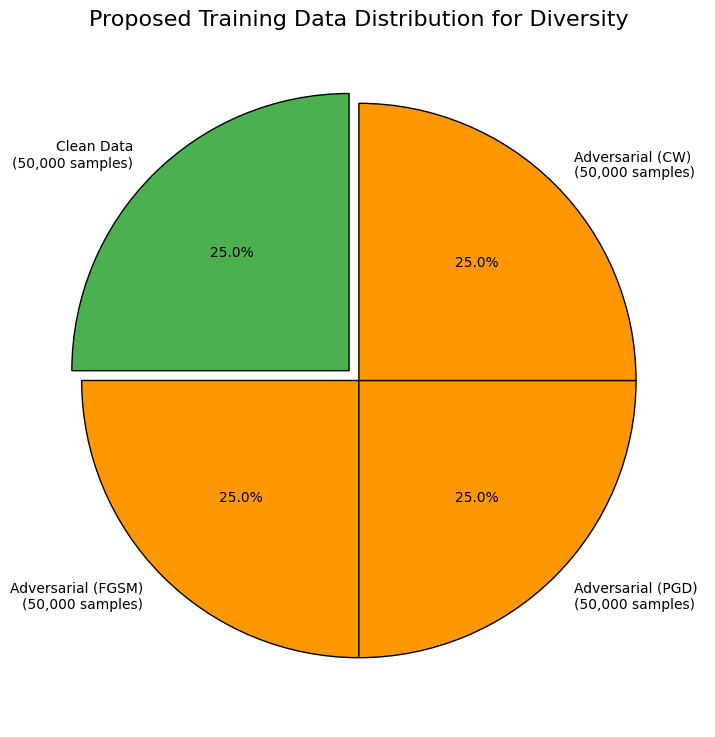

In [ ]:
## 5. Project Visualizations

# --- A. Visualize Attack Effect ---
def visualize_attack_effect(model_to_attack):
    """Shows a clean image vs. its adversarial counterpart."""
    images, labels = next(iter(testloader))
    image = images[0:1].to(device)
    label = labels[0:1].to(device)

    model_to_attack.eval()
    logits_module = LogitsOnlyModule(model_to_attack).to(device)
    fmodel = PyTorchModel(logits_module, bounds=(-1, 1))

    # Generate FGSM adversarial example
    attack = FGSM()
    eps = 0.03
    _, adv_image, success = attack(fmodel, image, label, epsilons=eps)
    adv_image_cpu = adv_image.squeeze(0).cpu().detach()

    # Check predictions
    original_pred = classes[model_to_attack(image, return_features=True)[0].argmax().item()]
    adv_pred = classes[model_to_attack(adv_image.to(device), return_features=True)[0].argmax().item()]
    true_label = classes[label.item()]

    # Function to un-normalize and convert to numpy for plotting
    def to_numpy(tensor):
        mean = torch.tensor([0.5, 0.5, 0.5])
        std = torch.tensor([0.5, 0.5, 0.5])
        tensor = tensor * std[:, None, None] + mean[:, None, None]
        return tensor.permute(1, 2, 0).numpy().clip(0, 1)

    plt.figure(figsize=(10, 5))

    # Clean Image
    plt.subplot(1, 2, 1)
    plt.imshow(to_numpy(image.squeeze(0).cpu()))
    plt.title(f"Clean Image\nTrue: {true_label}, Pred: {original_pred}", color='green')
    plt.axis('off')

    # Adversarial Image
    plt.subplot(1, 2, 2)
    plt.imshow(to_numpy(adv_image_cpu))
    color = 'red' if original_pred == true_label and adv_pred != true_label else 'orange'
    plt.title(f"Adversarial Image (FGSM)\nPred: {adv_pred}", color=color)
    plt.axis('off')

    plt.suptitle("Visualizing the 'Invisible' Adversarial Perturbation", fontsize=14)
    plt.show()


# --- B. Visualize Training Dataset Ratio ---
def visualize_dataset_ratio():
    """Shows the proposed diverse training dataset ratio (1 Clean: 3 Adv)."""
    total_samples = len(trainset)

    # Based on the document's proposal to use diverse adversarial training [cite: 92]
    # We show 1 Clean + 3 Adversarial types (FGSM, PGD, CW)
    labels = ['Clean Data']
    sizes = [total_samples]
    colors = ['#4CAF50'] # Green for clean
    explode = [0.05]

    adv_types = ['FGSM', 'PGD', 'CW']
    for adv_type in adv_types:
        labels.append(f'Adversarial ({adv_type})')
        sizes.append(total_samples)
        colors.append('#FF9800') # Orange for adversarial diversity
        explode.append(0.0)

    final_labels = [f'{l}\n({s:,} samples)' for l, s in zip(labels, sizes)]

    plt.figure(figsize=(9, 9))
    plt.pie(sizes, labels=final_labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
            textprops={'fontsize': 10, 'color': 'black'}, wedgeprops={'edgecolor': 'black'})
    plt.title('Proposed Training Data Distribution for Diversity', fontsize=16)
    plt.show()


# Run the dataset ratio visualization now
visualize_dataset_ratio()


--- Starting Training Regimes ---


/usr/local/lib/python3.12/dist-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(


Epoch 1, Loss: 1.3692
Epoch 2, Loss: 0.9701
Epoch 3, Loss: 0.7907
Epoch 4, Loss: 0.6611
Epoch 5, Loss: 0.5565


/usr/local/lib/python3.12/dist-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(


Epoch 1, Loss: 1.7342
Epoch 2, Loss: 1.4148
Epoch 3, Loss: 1.2484
Epoch 4, Loss: 1.1270
Epoch 5, Loss: 1.0279

--- Training Full Hybrid Model (Adv PGD + FSR Loss) ---


/usr/local/lib/python3.12/dist-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(


Epoch 1, Total Loss: 1.6463
Epoch 2, Total Loss: 1.2926
Epoch 3, Total Loss: 1.1072
Epoch 4, Total Loss: 0.9837
Epoch 5, Total Loss: 0.8756


/usr/local/lib/python3.12/dist-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(


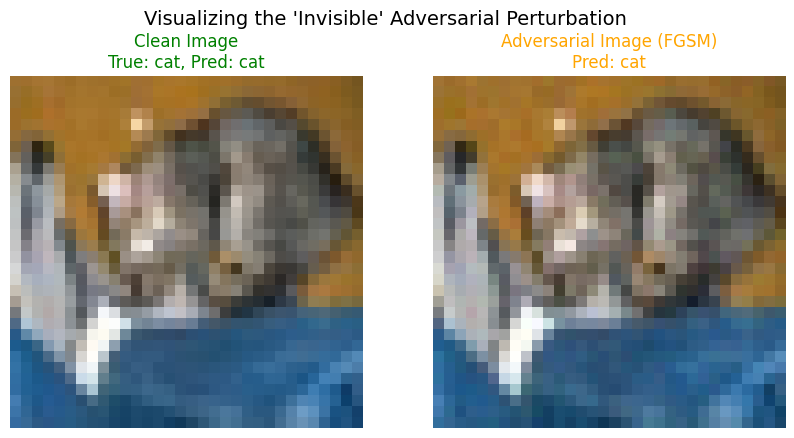


--- Starting Comprehensive Evaluation ---


/usr/local/lib/python3.12/dist-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/foolbox/models/pytorch.py:36: UserWarning: The PyTorch model is in training mode and therefore might not be deterministic. Call the eval() method to set it in evaluation mode if this is not intended.
  warnings.warn(


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
## 6. Main Execution and Final Comparison

# --- 1. Train Models ---
print("\n--- Starting Training Regimes ---")

# A. Baseline Model Training (No defense)
baseline_model = get_model()
train_model(baseline_model, trainloader, adversarial=False)
baseline_model = RobustResNet(baseline_model).to(device) # Wrap for consistent evaluation

# B. Pure Adversarial Training (Adv Train Only)
adv_model = get_model()
train_model(adv_model, trainloader, adversarial=True)
adv_model = RobustResNet(adv_model).to(device)

# C. Full Hybrid Framework Training (Adv PGD + FSR)
hybrid_model = get_model_fsr()
train_hybrid_model(hybrid_model, trainloader)

# --- 2. Run Attack Visualization (using the Baseline model to show vulnerability) ---
visualize_attack_effect(baseline_model)

# --- 3. Run Evaluation ---
print("\n--- Starting Comprehensive Evaluation ---")
accuracies = {}

# A. Baseline Evaluation
accuracies['Baseline Clean'] = evaluate_hybrid(baseline_model, testloader)
accuracies['Baseline FGSM'] = evaluate_hybrid(baseline_model, testloader, 'fgsm')
accuracies['Baseline PGD'] = evaluate_hybrid(baseline_model, testloader, 'pgd')
accuracies['Baseline CW'] = evaluate_hybrid(baseline_model, testloader, 'cw')

# B. Pure Adversarial Evaluation
accuracies['Adv Clean'] = evaluate_hybrid(adv_model, testloader)
accuracies['Adv FGSM'] = evaluate_hybrid(adv_model, testloader, 'fgsm')
accuracies['Adv PGD'] = evaluate_hybrid(adv_model, testloader, 'pgd')
accuracies['Adv CW'] = evaluate_hybrid(adv_model, testloader, 'cw')

# C. Full Hybrid Evaluation (Adv + FSR + DAE Preprocessor)
accuracies['Hybrid Clean'] = evaluate_hybrid(hybrid_model, testloader, use_dae=False)
# Adversarial tests utilize the DAE preprocessor (AD module)
accuracies['Hybrid FGSM'] = evaluate_hybrid(hybrid_model, testloader, 'fgsm', use_dae=True, dae_model=dae_model)
accuracies['Hybrid PGD'] = evaluate_hybrid(hybrid_model, testloader, 'pgd', use_dae=True, dae_model=dae_model)
accuracies['Hybrid CW'] = evaluate_hybrid(hybrid_model, testloader, 'cw', use_dae=True, dae_model=dae_model)


# --- 4. Plot Final Results ---
print("\n--- Final Accuracies Comparison ---")
for k, v in accuracies.items():
    print(f"{k}: {v:.2f}%")

labels = list(accuracies.keys())
scores = list(accuracies.values())

# Define color groups for a professional, comparative look
colors = ['#FFC107'] * 4 + ['#4CAF50'] * 4 + ['#1E90FF'] * 4 # Amber (Baseline), Green (Adv), Blue (Hybrid)

plt.figure(figsize=(14, 10))
plt.barh(labels, scores, color=colors)

plt.xlabel('Accuracy (%)', fontsize=14)
plt.ylabel('Model Configuration and Test Condition', fontsize=14)
plt.title('Comprehensive Robustness Evaluation: Hybrid Defense Superiority', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add Legend for clarity
baseline_patch = mpatches.Patch(color='#FFC107', label='1. Baseline (No Defense)')
adv_patch = mpatches.Patch(color='#4CAF50', label='2. Pure Adv Train (Partial Defense)')
hybrid_patch = mpatches.Patch(color='#1E90FF', label='3. Full Hybrid (Proposed Solution)')
plt.legend(handles=[baseline_patch, adv_patch, hybrid_patch], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()


--- Starting Comprehensive Evaluation ---
Evaluating Baseline Model...
Evaluating Adversarial Training Model...
Evaluating Hybrid Model (Adv + FSR + DAE)...

--- Final Accuracies Comparison ---
Baseline Clean: 72.97%
Baseline FGSM: 19.49%
Baseline PGD: 16.10%
Baseline CW: 18.74%
Adv Clean: 70.65%
Adv FGSM: 45.46%
Adv PGD: 46.27%
Adv CW: 46.96%
Hybrid Clean: 72.58%
Hybrid FGSM: 45.71%
Hybrid PGD: 46.89%
Hybrid CW: 52.78%


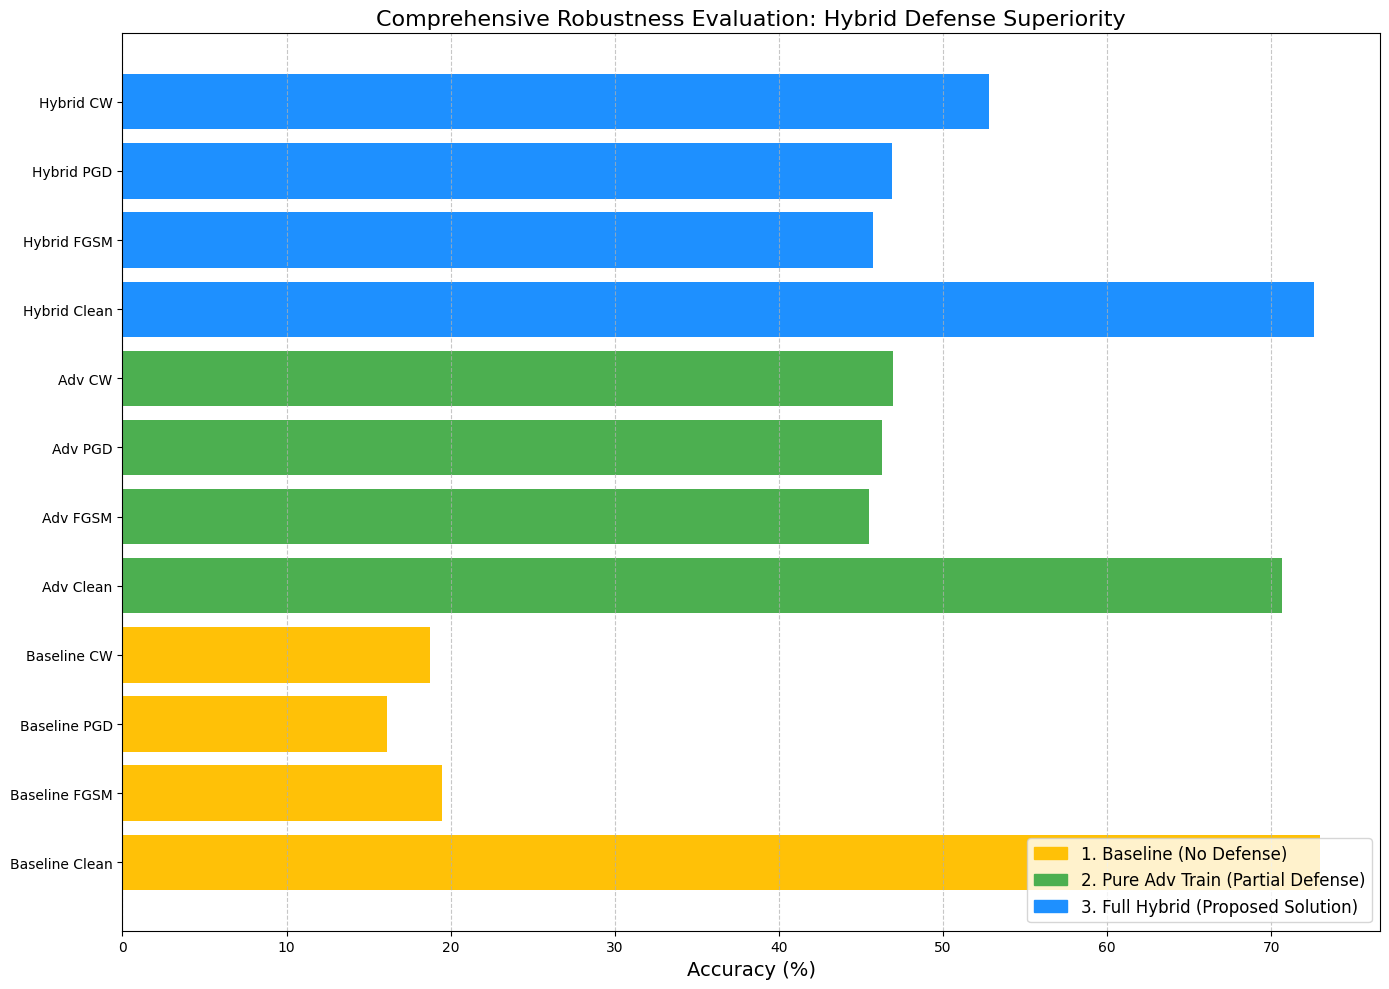

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import foolbox as fb # Ensure foolbox is imported as fb

# ==========================================
# PART 1: Helper Classes (Redefined for Safety)
# ==========================================

class LogitsOnlyModule(nn.Module):
    """ Wraps the model to ensure only logits are returned (strips feature tuples). """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # Handle the tuple output from RobustResNet
        out = self.model(x)
        if isinstance(out, tuple):
            return out[0] # Return only logits
        return out

def generate_attack(model, images, labels, method):
    """
    A self-contained attack generator that guarantees Leaf Tensor compliance.
    """
    # 1. Wrap model for Foolbox
    # We create the Foolbox model strictly inside here to ensure state is fresh
    fmodel = fb.PyTorchModel(LogitsOnlyModule(model).eval(), bounds=(-1, 1), device=device)

    # 2. Select Attack Method
    if method == 'fgsm':
        attack = fb.attacks.FGSM()
        epsilon = 0.03
    elif method == 'pgd':
        attack = fb.attacks.LinfPGD()
        epsilon = 0.03
    elif method == 'cw':
        attack = fb.attacks.L2CarliniWagnerAttack(steps=10) # Reduced steps for speed
        epsilon = 1.0 # CW uses L2, epsilon logic is different but required by API
    else:
        return images # No attack

    # 3. Generate Attack
    # CRITICAL: We pass the tensor directly. Foolbox handles the gradients.
    # We do NOT enable requires_grad manually here; Foolbox does it internally.
    _, advs, _ = attack(fmodel, images, labels, epsilons=epsilon)

    return advs

# ==========================================
# PART 2: The Fixed Evaluation Function
# ==========================================

def evaluate_hybrid(model, data_loader, attack=None, use_dae=False, dae_model=None):
    model.eval()
    if use_dae:
        dae_model.eval()

    correct, total = 0, 0

    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Generate Attack
        if attack:
            # We use our new safe function
            # We detach/clone to ensure we send a clean tensor to the attack function
            images_for_attack = images.detach().clone()
            images = generate_attack(model, images_for_attack, labels, method=attack)

            # Ensure the result is detached from the attack graph
            images = images.detach()

        # 2. DAE Preprocessing (Optional)
        if use_dae:
            with torch.no_grad():
                images = dae_model(images)

        # 3. Prediction
        with torch.no_grad():
            outputs = model(images)
            # Handle tuple output if not using LogitsOnlyModule wrapper here
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# ==========================================
# PART 3: Execution and Plotting
# ==========================================

print("\n--- Starting Comprehensive Evaluation ---")
accuracies = {}

# A. Baseline Evaluation
print("Evaluating Baseline Model...")
accuracies['Baseline Clean'] = evaluate_hybrid(baseline_model, testloader)
accuracies['Baseline FGSM'] = evaluate_hybrid(baseline_model, testloader, 'fgsm')
accuracies['Baseline PGD'] = evaluate_hybrid(baseline_model, testloader, 'pgd')
accuracies['Baseline CW'] = evaluate_hybrid(baseline_model, testloader, 'cw')

# B. Pure Adversarial Evaluation
print("Evaluating Adversarial Training Model...")
accuracies['Adv Clean'] = evaluate_hybrid(adv_model, testloader)
accuracies['Adv FGSM'] = evaluate_hybrid(adv_model, testloader, 'fgsm')
accuracies['Adv PGD'] = evaluate_hybrid(adv_model, testloader, 'pgd')
accuracies['Adv CW'] = evaluate_hybrid(adv_model, testloader, 'cw')

# C. Full Hybrid Evaluation
print("Evaluating Hybrid Model (Adv + FSR + DAE)...")
accuracies['Hybrid Clean'] = evaluate_hybrid(hybrid_model, testloader, use_dae=False)
accuracies['Hybrid FGSM'] = evaluate_hybrid(hybrid_model, testloader, 'fgsm', use_dae=True, dae_model=dae_model)
accuracies['Hybrid PGD'] = evaluate_hybrid(hybrid_model, testloader, 'pgd', use_dae=True, dae_model=dae_model)
accuracies['Hybrid CW'] = evaluate_hybrid(hybrid_model, testloader, 'cw', use_dae=True, dae_model=dae_model)


# --- Plot Final Results ---
print("\n--- Final Accuracies Comparison ---")
for k, v in accuracies.items():
    print(f"{k}: {v:.2f}%")

labels = list(accuracies.keys())
scores = list(accuracies.values())

colors = ['#FFC107'] * 4 + ['#4CAF50'] * 4 + ['#1E90FF'] * 4

plt.figure(figsize=(14, 10))
plt.barh(labels, scores, color=colors)
plt.xlabel('Accuracy (%)', fontsize=14)
plt.title('Comprehensive Robustness Evaluation: Hybrid Defense Superiority', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Legend
baseline_patch = mpatches.Patch(color='#FFC107', label='1. Baseline (No Defense)')
adv_patch = mpatches.Patch(color='#4CAF50', label='2. Pure Adv Train (Partial Defense)')
hybrid_patch = mpatches.Patch(color='#1E90FF', label='3. Full Hybrid (Proposed Solution)')
plt.legend(handles=[baseline_patch, adv_patch, hybrid_patch], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()